# CSCE 676 — Semester Project Checkpoint 2  
## Research Question Formation for MovieLens 25M

This notebook converts the earlier dataset selection and EDA work into a research-question-driven plan. The selected dataset is **MovieLens 25M**.

## 1. Project Scope

**Selected dataset:** MovieLens 25M  
**Course techniques:** Frequent itemset mining, association rule mining  
**External techniques:** Sequential pattern mining

### Main prior EDA observations
From the earlier analysis:

- item popularity is highly skewed
- user activity is highly skewed
- positive basket sizes are large and long-tailed
- rating activity is temporally clustered rather than uniform

These findings motivate research questions about support thresholds, rule quality metrics, and whether temporal order reveals structure that unordered itemsets miss.

## 2. Research Question Definition

### RQ1
**What frequent itemsets emerge under different minimum support thresholds when user transactions are defined by positively rated movies?**

- **Data mining task type:** Frequent itemset mining  
- **Relevant algorithm(s):** Apriori (course), FP-Growth as a scalable comparison  
- **Evaluation criteria:** support, number of discovered itemsets, average itemset length, interpretability, diversity of movie titles

### RQ2
**How do confidence and lift differ when evaluating association rules mined from positive user baskets?**

- **Data mining task type:** Association rule mining  
- **Relevant algorithm(s):** Apriori / FP-Growth + rule generation  
- **Evaluation criteria:** confidence, lift, support, redundancy, interpretability

### RQ3
**Do sequential patterns in user rating histories reveal structure that is missed by unordered frequent itemsets?**

- **Data mining task type:** Sequential pattern mining  
- **Relevant algorithm(s):** PrefixSpan (external)  
- **Evaluation criteria:** sequential support, novelty relative to unordered itemsets, interpretability, diversity of patterns

### RQ-to-Method Mapping Table

| RQ  | Question                                                                 | Task Type                   | Course or External | Algorithm(s)                          | Evaluation Criteria                                              |
|-----|-------------------------------------------------------------------------|-----------------------------|--------------------|----------------------------------------|------------------------------------------------------------------|
| RQ1 | What frequent itemsets emerge under different minimum support thresholds? | Frequent itemset mining     | Course             | Apriori / FP-Growth                   | support, # itemsets, itemset length, interpretability, diversity |
| RQ2 | How do confidence and lift differ when evaluating association rules?     | Association rule mining     | Course             | Apriori / FP-Growth + rule generation | confidence, lift, support, redundancy, interpretability          |
| RQ3 | Do sequential patterns reveal structure missed by unordered itemsets?    | Sequential pattern mining   | External           | PrefixSpan                            | sequential support, novelty, interpretability, diversity         |

### Database Setup & Summary

In [14]:
# Standard data/EDA stack
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from collections import Counter
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 4)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [ ]:
from google.colab import files
uploaded = files.upload()

In [15]:
DATA_DIR = Path("/content")

ratings_path = DATA_DIR / "ratings.csv"
movies_path  = DATA_DIR / "movies.csv"


ratings = pd.read_csv(ratings_path)
movies = pd.read_csv(movies_path)

ratings exists: True /content/ratings.csv
movies exists:  True /content/movies.csv


In [17]:
# Run this cell after loading ratings and movies.

required_cols_ratings = {"userId", "movieId", "rating", "timestamp"}
required_cols_movies = {"movieId", "title"}

assert required_cols_ratings.issubset(ratings.columns), f"ratings.csv missing columns: {required_cols_ratings - set(ratings.columns)}"
assert required_cols_movies.issubset(movies.columns), f"movies.csv missing columns: {required_cols_movies - set(movies.columns)}"

print("ratings shape:", ratings.shape)
print("movies shape:", movies.shape)
print("\nratings columns:", list(ratings.columns))
print("\nmovies columns:", list(movies.columns))
print("\nratings missingness:")
print(ratings.isna().mean())

ratings shape: (25000095, 4)
movies shape: (62423, 3)

ratings columns: ['userId', 'movieId', 'rating', 'timestamp']

movies columns: ['movieId', 'title', 'genres']

ratings missingness:
userId       0.0
movieId      0.0
rating       0.0
timestamp    0.0
dtype: float64


### Additional EDA Needed for RQ Formation

The earlier checkpoint already established that MovieLens is large, sparse, and temporally skewed.  
For Checkpoint 2, I need a little more targeted EDA to make sure the proposed methods are both interesting and feasible.

The extra EDA below focuses on:

- **positive basket sizes** for frequent itemset mining  
- **movie popularity distribution** for bias and support-threshold reasoning  
- **temporal activity** for sequence motivation  
- **sequence length per user** for sequential pattern mining feasibility

#### Create Positive Transactions

I decided to define a movie as "present" in a user's transaction if the user rated it **4.0 or higher**.  
I chose this threshold because it creates a clearer notion of positive preference than using all ratings equally. This decision makes the transactional interpretation more meaningful for itemset and association rule mining.

In [18]:
POS_RATING_THRESHOLD = 4.0

positive_ratings = ratings.loc[ratings["rating"] >= POS_RATING_THRESHOLD].copy()
positive_ratings["datetime"] = pd.to_datetime(positive_ratings["timestamp"], unit="s", errors="coerce")

print("positive_ratings shape:", positive_ratings.shape)
print("unique users with >= 4.0 ratings:", positive_ratings["userId"].nunique())
print("unique movies with >= 4.0 ratings:", positive_ratings["movieId"].nunique())

positive_ratings shape: (12452811, 5)
unique users with >= 4.0 ratings: 162342
unique movies with >= 4.0 ratings: 40858


#### Basket Size Distribution

Basket sizes because basket size directly affects Apriori/FP-Growth feasibility. Large, long-tailed baskets can cause candidate explosion, so this is important for both method choice and parameter planning.

count    162342.000000
mean         76.707266
std         109.462737
min           1.000000
50%          40.000000
90%         177.000000
95%         261.000000
99%         524.000000
max        5525.000000
Name: movieId, dtype: float64


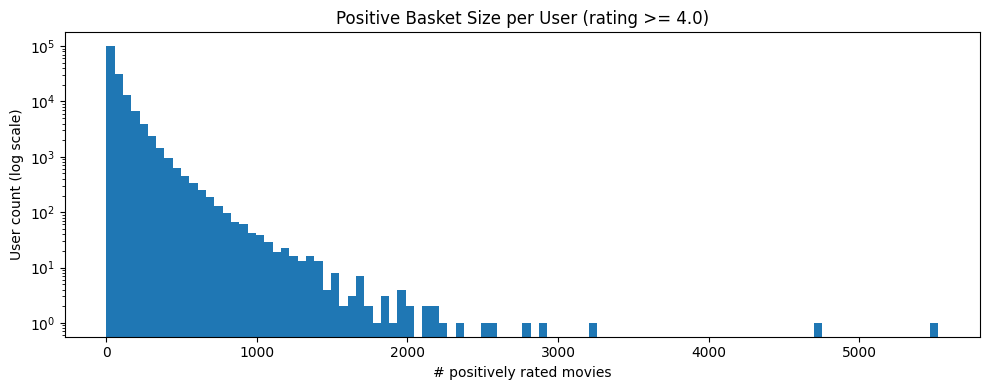

In [19]:
basket_sizes = positive_ratings.groupby("userId")["movieId"].nunique()

print(basket_sizes.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure()
basket_sizes.plot(kind="hist", bins=100, log=True)
plt.title("Positive Basket Size per User (rating >= 4.0)")
plt.xlabel("# positively rated movies")
plt.ylabel("User count (log scale)")
plt.tight_layout()
plt.show()

#### Movie Popularity Distribution

Inspecting ratings-per-movie because support thresholds will likely be dominated by blockbuster titles if movie popularity is highly skewed. This helps motivate RQ1 and RQ2.

count    59047.000000
mean       423.393144
std       2477.885821
min          1.000000
50%          6.000000
90%        413.000000
95%       1503.400000
99%       9941.620000
max      81491.000000
dtype: float64


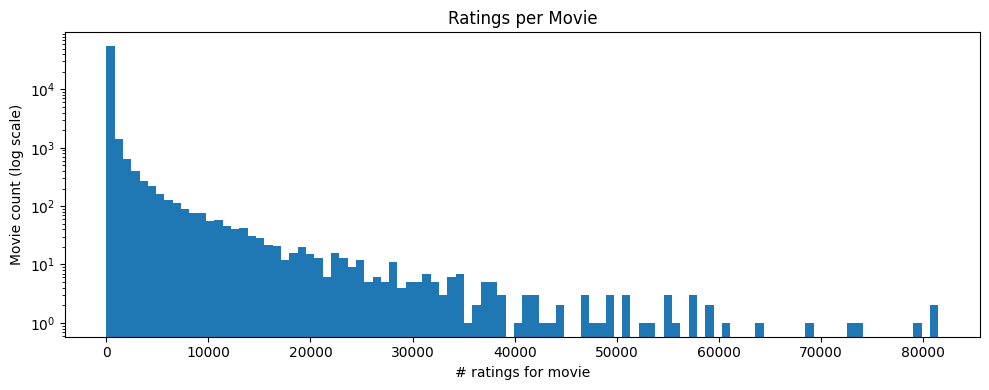

,movieId,title,rating_count
0,356,Forrest Gump (1994),81491
1,318,"Shawshank Redemption, The (1994)",81482
2,296,Pulp Fiction (1994),79672
3,593,"Silence of the Lambs, The (1991)",74127
4,2571,"Matrix, The (1999)",72674
5,260,Star Wars: Episode IV - A New Hope (1977),68717
6,480,Jurassic Park (1993),64144
7,527,Schindler's List (1993),60411
8,110,Braveheart (1995),59184
9,2959,Fight Club (1999),58773


In [20]:
ratings_per_movie = ratings.groupby("movieId").size()

print(ratings_per_movie.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure()
ratings_per_movie.plot(kind="hist", bins=100, log=True)
plt.title("Ratings per Movie")
plt.xlabel("# ratings for movie")
plt.ylabel("Movie count (log scale)")
plt.tight_layout()
plt.show()

top_movies = ratings_per_movie.sort_values(ascending=False).head(10).rename("rating_count").reset_index()
top_movies = top_movies.merge(movies[["movieId", "title"]], on="movieId", how="left")
top_movies[["movieId", "title", "rating_count"]]

#### Temporal Activity

Aggregating ratings by month because this is a simple way to check whether user behavior is temporally uniform. If activity is clustered, that strengthens the case for an external sequence-aware method.

count       287.000000
mean      87108.344948
std       54939.227075
min           3.000000
25%       54491.000000
50%       76950.000000
75%      111709.500000
max      400997.000000
dtype: float64

Max / median month ratio: 5.211137102014295


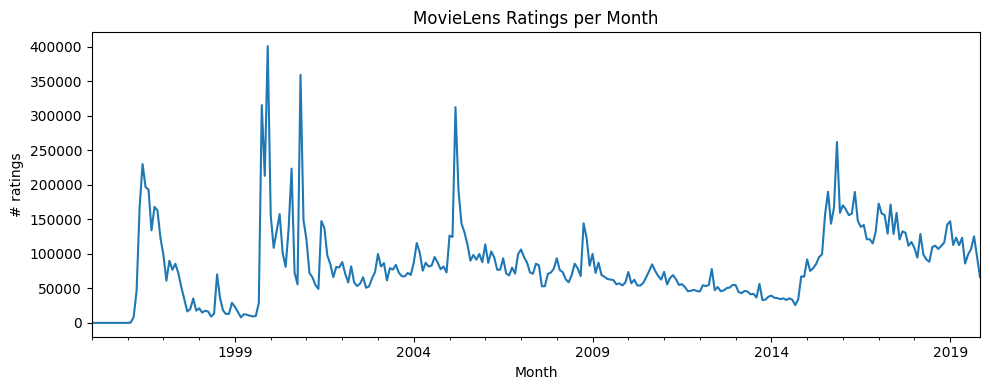

In [21]:
ratings["datetime"] = pd.to_datetime(ratings["timestamp"], unit="s", errors="coerce")
ratings_per_month = ratings.groupby(ratings["datetime"].dt.to_period("M")).size().sort_index()

print(ratings_per_month.describe())
print("\nMax / median month ratio:", float(ratings_per_month.max()) / float(ratings_per_month.median()))

plt.figure()
ratings_per_month.plot()
plt.title("MovieLens Ratings per Month")
plt.xlabel("Month")
plt.ylabel("# ratings")
plt.tight_layout()
plt.show()

#### Sequence Length Feasibility Check

For sequential pattern mining, I need ordered histories for each user. The most important feasibility question here is sequence length: if user sequences are too short, sequential mining will be weak; if they are too long, mining may become expensive.

count    162342.000000
mean         76.707266
std         109.462737
min           1.000000
50%          40.000000
90%         177.000000
95%         261.000000
99%         524.000000
max        5525.000000
dtype: float64


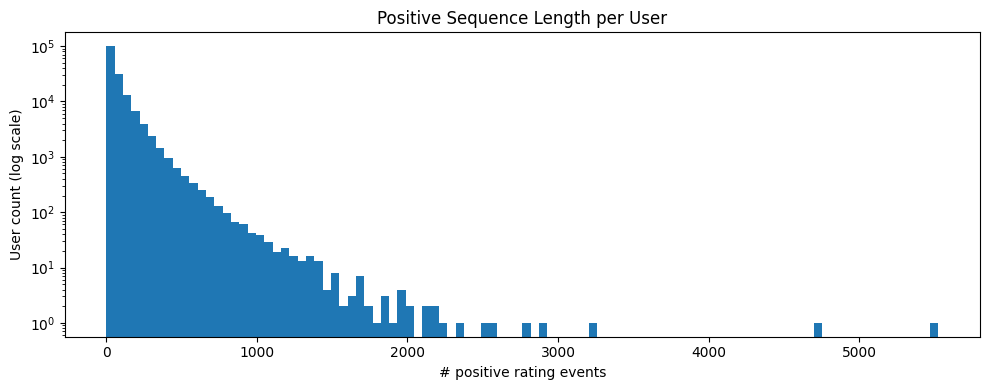

In [22]:
user_sequence_lengths = (
    positive_ratings
    .sort_values(["userId", "timestamp"])
    .groupby("userId")
    .size()
)

print(user_sequence_lengths.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

plt.figure()
user_sequence_lengths.plot(kind="hist", bins=100, log=True)
plt.title("Positive Sequence Length per User")
plt.xlabel("# positive rating events")
plt.ylabel("User count (log scale)")
plt.tight_layout()
plt.show()

#### Support Threshold Feasibility Check

In [23]:
candidate_supports = [0.10, 0.05, 0.02, 0.01, 0.005]

n_transactions = basket_sizes.shape[0]
support_table = pd.DataFrame({
    "min_support": candidate_supports,
    "min_transaction_count": [math.ceil(s * n_transactions) for s in candidate_supports]
})

support_table

,min_support,min_transaction_count
0,0.100,16235
1,0.050,8118
2,0.020,3247
3,0.010,1624
4,0.005,812


## 3. Motivation and Feasibility

### Motivation
The EDA shows that MovieLens has strong long-tail behavior in both users and movies, large variation in positive basket size, and temporally clustered activity. These properties make it a good setting for studying how pattern discovery changes under different assumptions.

### Non-triviality
A simple high-support rule-mining setup will likely overemphasize blockbuster movies. Sequential methods may reveal order-sensitive structure that is invisible when user history is collapsed into unordered baskets.

### Feasibility
- Frequent itemset mining is feasible with pruning through support thresholds and possible item filtering.
- Association rule mining is feasible after itemset generation.
- Sequential pattern mining is feasible if I restrict to filtered positive histories and control minimum support.

### Risks
- low support thresholds may cause Apriori candidate explosion
- confidence alone may overrate popular-item rules
- sequence mining may be sensitive to support and sequence-length filtering

## 4. Initial Methodological Planning

### Planned course algorithms
- **Apriori**: main course baseline for itemsets  
- **FP-Growth**: optional scalability-oriented comparison  
- **Association rule generation**: compare confidence vs. lift

### Planned external algorithm
- **PrefixSpan** for sequential pattern mining

### Planned preprocessing
- convert ratings into positive baskets using rating >= 4.0  
- sort positive ratings by timestamp for user sequences  
- optionally filter very rare movies if needed for tractability  
- optionally cap very long histories if sequential mining becomes too expensive

### Baselines
- high-support frequent itemset mining  
- association rules ranked only by confidence  
- unordered basket mining as the comparison baseline for sequence mining

### Initial Feasibility / Package Tests

In [25]:
!pip -q install prefixspan

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


In [26]:
from prefixspan import PrefixSpan

### Build a small sequence sample for feasibility testing

I start with a small subset of user sequences because the goal here is just to verify the pipeline and data format, not to run the final experiment yet.

In [27]:
MIN_SEQ_LEN = 5
MAX_USERS_FOR_TEST = 1000

eligible_users = user_sequence_lengths[user_sequence_lengths >= MIN_SEQ_LEN].index[:MAX_USERS_FOR_TEST]

sequence_df = (
    positive_ratings.loc[positive_ratings["userId"].isin(eligible_users), ["userId", "movieId", "timestamp"]]
    .sort_values(["userId", "timestamp"])
)

user_sequences = sequence_df.groupby("userId")["movieId"].apply(list).tolist()

print("Number of test sequences:", len(user_sequences))
print("Example sequence lengths:", [len(seq) for seq in user_sequences[:5]])
print("First sequence preview:", user_sequences[0][:20] if user_sequences else [])

Number of test sequences: 1000
Example sequence lengths: [39, 113, 357, 104, 58]
First sequence preview: [5952, 1653, 1250, 6377, 3448, 1088, 6711, 3949, 8360, 5878, 307, 1237, 8154, 7234, 2843, 4144, 7365, 4973, 6016, 2692]


In [29]:
ps = PrefixSpan(user_sequences)
patterns = ps.topk(10, closed=True)
patterns[:5]

[(412, [318]), (370, [296]), (362, [356]), (343, [593]), (325, [2571])]

## 5. Method and Metric Plan

### Methods
- Apriori or FP-Growth for frequent itemsets
- association rule generation for rule comparison
- PrefixSpan for sequential pattern mining

### Metrics / evaluation criteria
- **Itemsets:** support, number of itemsets, average length, diversity, interpretability  
- **Rules:** confidence, lift, support, redundancy, interpretability  
- **Sequences:** sequential support, novelty compared to unordered itemsets, diversity, interpretability

## 6. Collaboration Declaration

### Collabarators
N/A

### Web Sources
- Apriori (mlxtend): https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/apriori/
- Association Rules: https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/association_rules/
- PrefixSpan: https://www.philippe-fournier-viger.com/spmf/PrefixSpan.php
- MovieLens Dataset: https://grouplens.org/datasets/movielens/

### AI Tools

ChatGpt:
- Helped me brainstorm RQ ideas and which tests I need to do to verify validity of the question.
- Helped me dispaly the data nicer and understand the trends and its importance to the questions.

### References

[1] "FP-Growth Algorithm," Wikipedia.  
https://en.wikipedia.org/wiki/FP-growth_algorithm

[2] J. Han, H. Cheng, D. Xin, and X. Yan, "Frequent pattern mining: current status and future directions," 2007.  
https://www.cs.uic.edu/~liub/PMarchive/Survey-SPM.pdf

[3] Järv, P. (2019). *Predictability limits in session-based next item recommendation*. Proceedings of the 13th ACM Conference on Recommender Systems (RecSys ’19), 146–150. https://doi.org/10.1145/3298689.3346990

[4] Koren, Y. (2008). *Factorization meets the neighborhood: A multifaceted collaborative filtering model*. Proceedings of the 14th ACM SIGKDD International Conference on Knowledge Discovery and Data Mining (KDD ’08), 426–434. https://doi.org/10.1145/1401890.1401944